# 01 - Dataset, Calidad y EDA

---

**Objetivo:** Entender el dataset, validar calidad de datos, detectar problemas, y generar visualizaciones clave.

**Entregable:** Dataset entendido, validado, y listo para el pipeline de Integrante 2.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

from src.data.load_data import download_dataset, save_raw
from src.data.data_validation import (
    run_all_checks_raw,
    run_all_checks_clean,
    print_check_results,
)

print('Librerías cargadas.')

Librerías cargadas.


## 1. Carga del Dataset Crudo

---

In [ ]:
csv_path = download_dataset()
df_raw = pd.read_csv(csv_path)

print(f'Shape: {df_raw.shape}')
print(f'Columnas: {df_raw.columns.tolist()}')
df_raw.head(10)

Shape: (1186, 7)
Columnas: ['Company', 'Valuation ($B)', 'Date Joined', 'Country', 'City\xa0', 'Industry', 'Investors']


,Company,Valuation ($B),Date Joined,Country,City,Industry,Investors
0,ByteDance,$140,4/7/2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$127,12/1/2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100,7/3/2018,China,Shenzhen,E-commerce & direct-to-consumer,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95,1/23/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG"
4,Canva,$40,1/8/2018,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat..."
5,Checkout.com,$40,5/2/2019,United Kingdom,London,Fintech,"Tiger Global Management, Insight Partners, DST..."
6,Instacart,$39,12/30/2014,United States,San Francisco,"Supply chain, logistics, & delivery","Khosla Ventures, Kleiner Perkins Caufield & By..."
7,Databricks,$38,2/5/2019,United States,San Francisco,Data management & analytics,"Andreessen Horowitz, New Enterprise Associates..."
8,Revolut,$33,4/26/2018,United Kingdom,London,Fintech,"index Ventures, DST Global, Ribbit Capital"
9,Epic Games,$31.50,10/26/2018,United States,Cary,Other,"Tencent Holdings, KKR, Smash Ventures"


In [3]:
# Guardar crudo en data/raw/
raw_path = save_raw(df_raw)
print(f'Crudo guardado en: {raw_path}')

Crudo guardado en: data/raw\dataset_raw.csv


## 2. Validación de Calidad - Datos Crudos

---

In [4]:
raw_checks = run_all_checks_raw(df_raw)
print_check_results('VALIDACIÓN - DATOS CRUDOS', raw_checks)


  VALIDACIÓN - DATOS CRUDOS

  [PASS] required_columns
    missing_columns: []

  [PASS] no_duplicates
    n_duplicates: 0

  [PASS] nulls
    null_pct_per_column: {'Company': 0.0, 'Valuation ($B)': 0.0, 'Date Joined': 0.0, 'Country': 0.0, 'City\xa0': 0.0, 'Industry': 0.0, 'Investors': 1.52}
    columns_over_limit: {}

  [PASS] dates_parseable
    n_failed: 0
    n_total: 1186

  [PASS] shifted_rows
    n_shifted_rows: 0
    indices: []


## 3. Exploración Inicial

---

In [5]:
print('Tipos de datos:')
print(df_raw.dtypes)
print()
print('Info del dataset:')
print(f'  Filas: {df_raw.shape[0]}')
print(f'  Columnas: {df_raw.shape[1]}')
print(f'  Memoria: {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB')

Tipos de datos:
Company           object
Valuation ($B)    object
Date Joined       object
Country           object
City              object
Industry          object
Investors         object
dtype: object

Info del dataset:
  Filas: 1186
  Columnas: 7
  Memoria: 588.7 KB


In [6]:
# Limpiar nombre City\xa0
df_raw.columns = [c.strip().replace('\xa0', '') for c in df_raw.columns]
print('Columnas limpiadas:', df_raw.columns.tolist())

Columnas limpiadas: ['Company', 'Valuation ($B)', 'Date Joined', 'Country', 'City', 'Industry', 'Investors']


In [7]:
print('Valores nulos por columna:')
nulls = df_raw.isnull().sum()
print(nulls[nulls > 0])
print(f'\nTotal filas con al menos un null: {df_raw.isnull().any(axis=1).sum()}')

Valores nulos por columna:
Investors    18
dtype: int64

Total filas con al menos un null: 18


In [8]:
print('Filas duplicadas:', df_raw.duplicated().sum())
print()
print('Empresas duplicadas:', df_raw['Company'].duplicated().sum())

Filas duplicadas: 0

Empresas duplicadas: 3


## 4. Limpieza y Feature Engineering

---

In [9]:
df = df_raw.copy()

# Limpiar nombre City\xa0
df.columns = [c.strip().replace('\xa0', '') for c in df.columns]

# valuation_b: limpiar $ y convertir a número
df['valuation_b'] = (
    df['Valuation ($B)']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df['valuation_b'] = pd.to_numeric(df['valuation_b'], errors='coerce')

# date_joined: convertir a datetime
df['date_joined'] = pd.to_datetime(df['Date Joined'], errors='coerce')
df['join_year'] = df['date_joined'].dt.year.astype('Int64')
df['join_month'] = df['date_joined'].dt.month.astype('Int64')

# investor_count: contar inversores
df['investor_count'] = df['Investors'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).strip() else 0
)

# Renombrar columnas a formato limpio
df = df.rename(columns={
    'Company': 'company',
    'Country': 'country',
    'City': 'city',
    'Industry': 'industry',
    'Investors': 'investors',
})

print('Columnas finales:', df.columns.tolist())
df.head()

Columnas finales: ['company', 'Valuation ($B)', 'Date Joined', 'country', 'city', 'industry', 'investors', 'valuation_b', 'date_joined', 'join_year', 'join_month', 'investor_count']


,company,Valuation ($B),Date Joined,country,city,industry,investors,valuation_b,date_joined,join_year,join_month,investor_count
0,ByteDance,$140,4/7/2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S...",140.0,2017-04-07,2017,4,4
1,SpaceX,$127,12/1/2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen...",127.0,2012-12-01,2012,12,3
2,SHEIN,$100,7/3/2018,China,Shenzhen,E-commerce & direct-to-consumer,"Tiger Global Management, Sequoia Capital China...",100.0,2018-07-03,2018,7,3
3,Stripe,$95,1/23/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG",95.0,2014-01-23,2014,1,3
4,Canva,$40,1/8/2018,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat...",40.0,2018-01-08,2018,1,3


In [10]:
print('Tipos de datos después de limpieza:')
print(df[['valuation_b', 'date_joined', 'join_year', 'join_month', 'investor_count']].dtypes)
print()
print('Nulos después de limpieza:')
print(df[['valuation_b', 'date_joined', 'join_year', 'join_month', 'investor_count']].isnull().sum())

Tipos de datos después de limpieza:
valuation_b              float64
date_joined       datetime64[ns]
join_year                  Int64
join_month                 Int64
investor_count             int64
dtype: object

Nulos después de limpieza:
valuation_b       0
date_joined       0
join_year         0
join_month        0
investor_count    0
dtype: int64


## 5. Validación - Datos Limpios

---

In [11]:
clean_checks = run_all_checks_clean(df)
print_check_results('VALIDACIÓN - DATOS LIMPIOS', clean_checks)


  VALIDACIÓN - DATOS LIMPIOS

  [PASS] required_columns
    missing_columns: []

  [PASS] no_duplicates
    n_duplicates: 0

  [PASS] nulls
    null_pct_per_column: {'company': 0.0, 'Valuation ($B)': 0.0, 'Date Joined': 0.0, 'country': 0.0, 'city': 0.0, 'industry': 0.0, 'valuation_b': 0.0, 'date_joined': 0.0, 'join_year': 0.0, 'join_month': 0.0, 'investor_count': 0.0}
    columns_over_limit: {}

  [PASS] valuation_numeric
    dtype: float64
    n_nan: 0

  [PASS] target_range
    min: 1.0
    max: 140.0
    n_negative: 0
    n_over_1000: 0


## 6. Análisis del Target (valuation_b)

---

In [12]:
print('Estadísticas de valuation_b (miles de millones USD):')
print(df['valuation_b'].describe())

Estadísticas de valuation_b (miles de millones USD):
count    1186.000000
mean        3.251282
std         7.641574
min         1.000000
25%         1.100000
50%         1.600000
75%         3.000000
max       140.000000
Name: valuation_b, dtype: float64


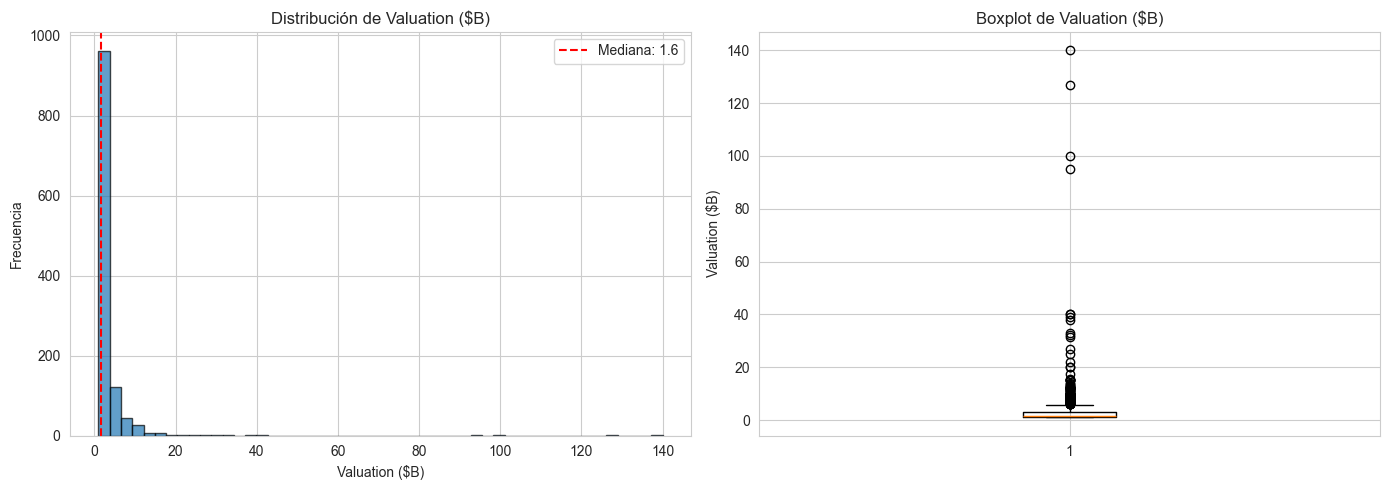

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['valuation_b'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Valuation ($B)')
axes[0].set_xlabel('Valuation ($B)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['valuation_b'].median(), color='red', linestyle='--', label=f'Mediana: {df["valuation_b"].median():.1f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['valuation_b'].dropna(), vert=True)
axes[1].set_title('Boxplot de Valuation ($B)')
axes[1].set_ylabel('Valuation ($B)')

plt.tight_layout()
plt.show()

In [14]:
print('Top 10 empresas más valiosas:')
df.nlargest(10, 'valuation_b')[['company', 'valuation_b', 'country', 'industry']]

Top 10 empresas más valiosas:


,company,valuation_b,country,industry
0,ByteDance,140.0,China,Artificial intelligence
1,SpaceX,127.0,United States,Other
2,SHEIN,100.0,China,E-commerce & direct-to-consumer
3,Stripe,95.0,United States,Fintech
4,Canva,40.0,Australia,Internet software & services
5,Checkout.com,40.0,United Kingdom,Fintech
6,Instacart,39.0,United States,"Supply chain, logistics, & delivery"
7,Databricks,38.0,United States,Data management & analytics
8,Revolut,33.0,United Kingdom,Fintech
10,FTX,32.0,Bahamas,"Sequoia Capital, Thoma Bravo, Softbank"


## 7. Distribución por País

---

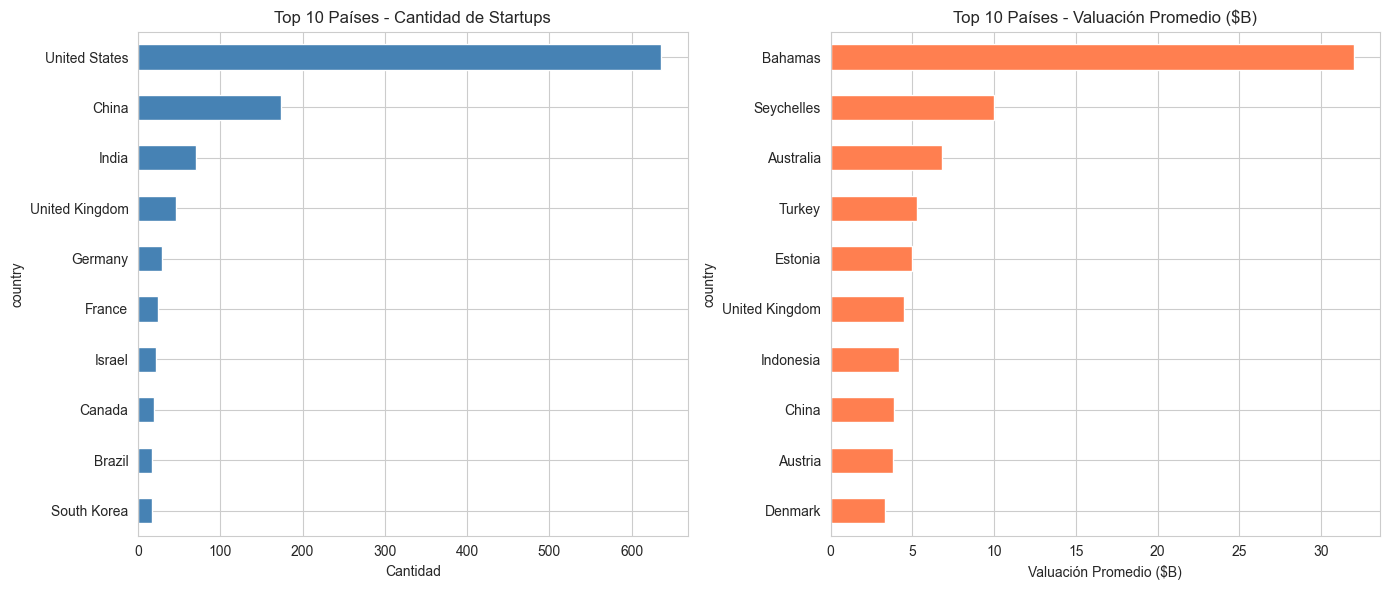

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 paises por cantidad de startups
country_counts = df['country'].value_counts().head(10)
country_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Países - Cantidad de Startups')
axes[0].set_xlabel('Cantidad')
axes[0].invert_yaxis()

# Top 10 paises por valuacion promedio
country_val = df.groupby('country')['valuation_b'].mean().nlargest(10)
country_val.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Países - Valuación Promedio ($B)')
axes[1].set_xlabel('Valuación Promedio ($B)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Distribución por Industria

---

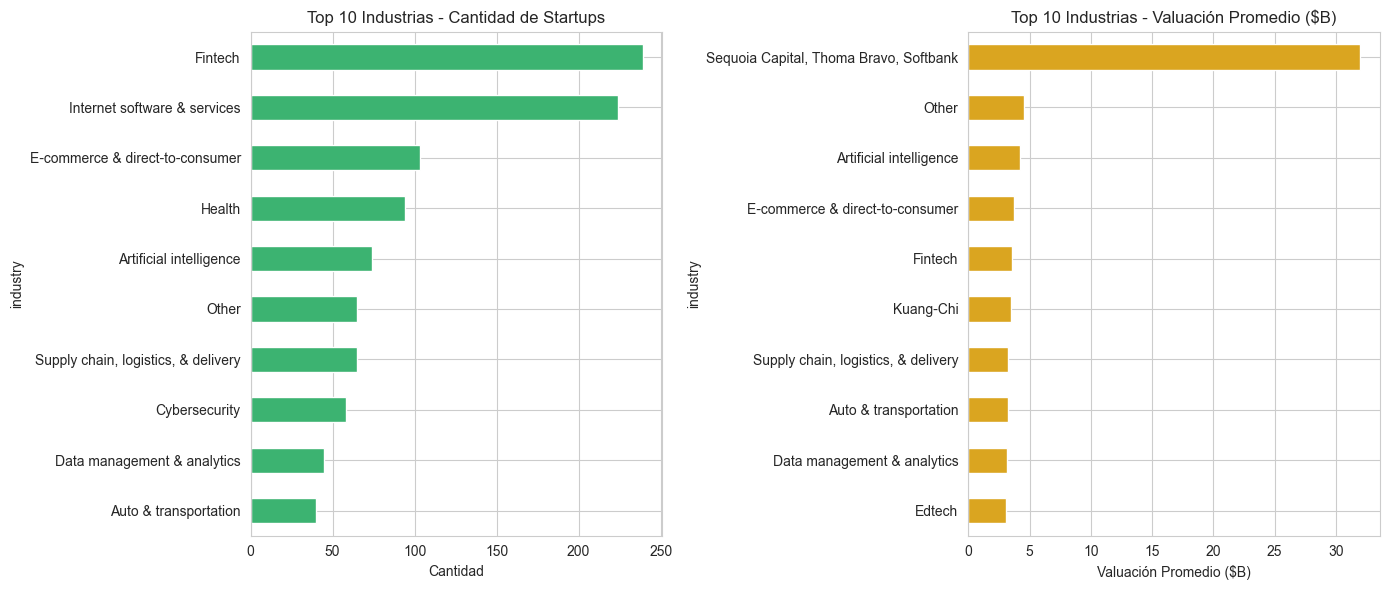

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 industrias por cantidad
ind_counts = df['industry'].value_counts().head(10)
ind_counts.plot(kind='barh', ax=axes[0], color='mediumseagreen')
axes[0].set_title('Top 10 Industrias - Cantidad de Startups')
axes[0].set_xlabel('Cantidad')
axes[0].invert_yaxis()

# Top 10 industrias por valuacion promedio
ind_val = df.groupby('industry')['valuation_b'].mean().nlargest(10)
ind_val.plot(kind='barh', ax=axes[1], color='goldenrod')
axes[1].set_title('Top 10 Industrias - Valuación Promedio ($B)')
axes[1].set_xlabel('Valuación Promedio ($B)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Startups por Año de Incorporación

---

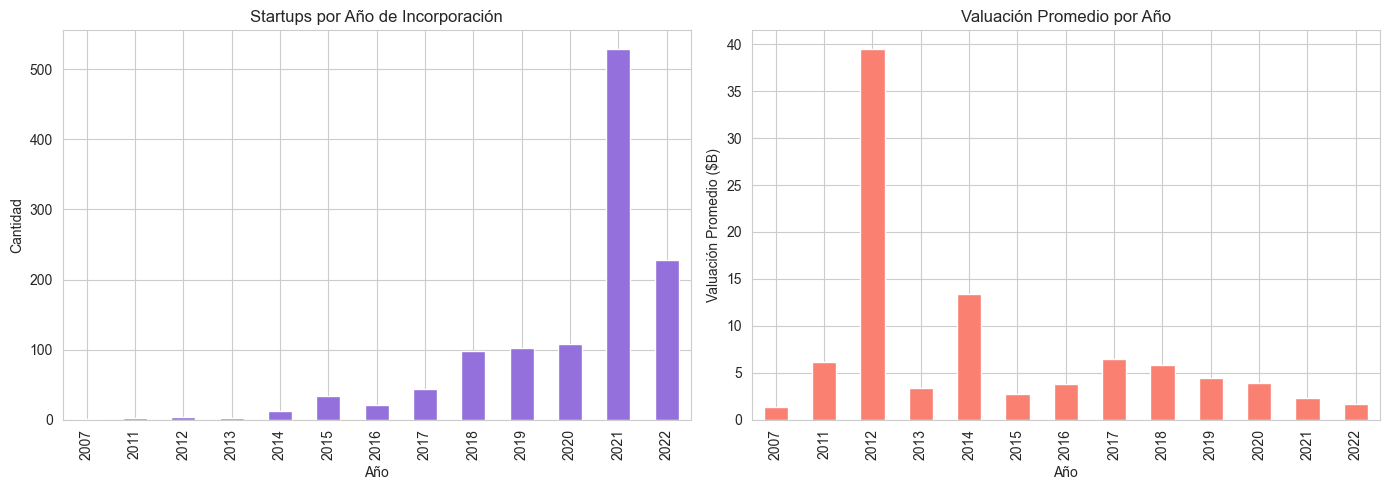

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cantidad de startups por ano
year_counts = df['join_year'].value_counts().sort_index()
year_counts.plot(kind='bar', ax=axes[0], color='mediumpurple')
axes[0].set_title('Startups por Año de Incorporación')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad')

# Valuacion promedio por ano
year_val = df.groupby('join_year')['valuation_b'].mean()
year_val.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Valuación Promedio por Año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Valuación Promedio ($B)')

plt.tight_layout()
plt.show()

## 10. Outliers en Valuation

---

In [18]:
Q1 = df['valuation_b'].quantile(0.25)
Q3 = df['valuation_b'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[df['valuation_b'] > upper]
print('IQR: {:.2f}'.format(IQR))
print('Límite superior: {:.2f}'.format(upper))
print('Outliers detectados: {}'.format(len(outliers)))
print()
print('Empresas outliers (valuation > {:.2f}B):'.format(upper))
outliers[['company', 'valuation_b', 'country', 'industry']].head(15)

IQR: 1.90
Límite superior: 5.85
Outliers detectados: 117

Empresas outliers (valuation > 5.85B):


,company,valuation_b,country,industry
0,ByteDance,140.0,China,Artificial intelligence
1,SpaceX,127.0,United States,Other
2,SHEIN,100.0,China,E-commerce & direct-to-consumer
3,Stripe,95.0,United States,Fintech
4,Canva,40.0,Australia,Internet software & services
5,Checkout.com,40.0,United Kingdom,Fintech
6,Instacart,39.0,United States,"Supply chain, logistics, & delivery"
7,Databricks,38.0,United States,Data management & analytics
8,Revolut,33.0,United Kingdom,Fintech
9,Epic Games,31.5,United States,Other


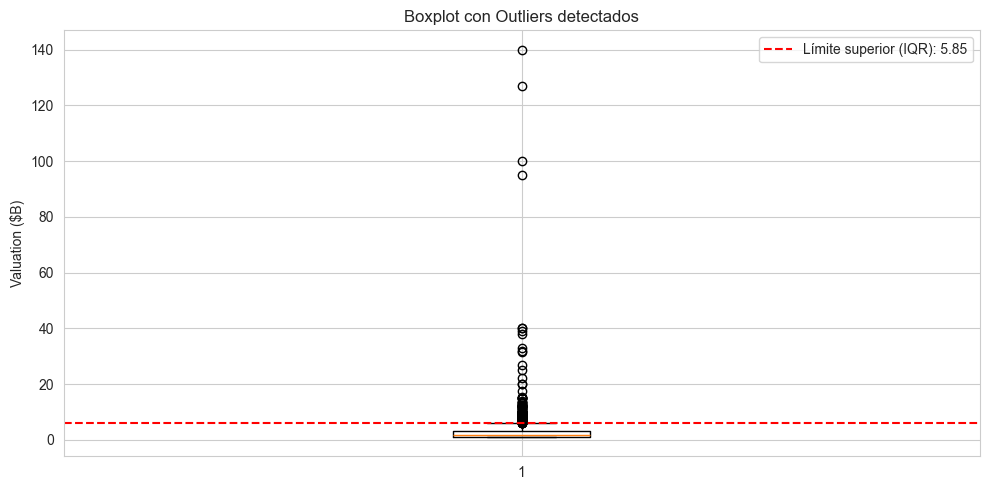

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(df['valuation_b'].dropna(), vert=True)
ax.axhline(upper, color='red', linestyle='--', label='Límite superior (IQR): {:.2f}'.format(upper))
ax.set_title('Boxplot con Outliers detectados')
ax.set_ylabel('Valuation ($B)')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Correlaciones

---

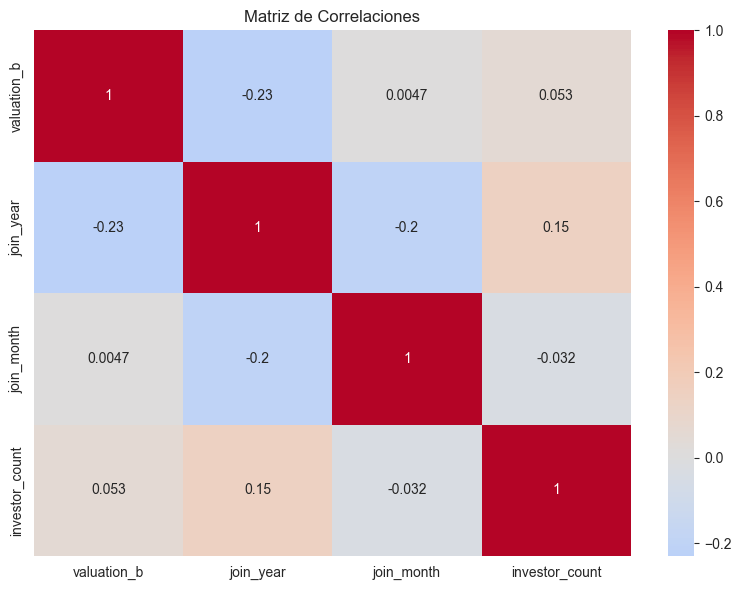

In [20]:
num_cols = ['valuation_b', 'join_year', 'join_month', 'investor_count']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matriz de Correlaciones')
plt.tight_layout()
plt.show()

## 12. Análisis de Nulos en Investors

---

In [21]:
null_investors = df[df['investor_count'] == 0]
print('Filas con investors_count = 0 (originalmente NaN): {}'.format(len(null_investors)))
print()
if len(null_investors) > 0:
    print('Estas filas tienen Investors NaN en el original:')
    null_investors[['company', 'valuation_b', 'country', 'industry']].head(10)

Filas con investors_count = 0 (originalmente NaN): 18

Estas filas tienen Investors NaN en el original:


## 13. Guardado del Dataset Limpio

---

In [22]:
# Guardar version limpia en data/processed/
os.makedirs('../data/processed', exist_ok=True)
processed_path = '../data/processed/dataset_clean.csv'
df.to_csv(processed_path, index=False)
print(f'Dataset limpio guardado en: {processed_path}')
print(f'Shape: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')

Dataset limpio guardado en: ../data/processed/dataset_clean.csv
Shape: (1186, 12)
Columnas: ['company', 'Valuation ($B)', 'Date Joined', 'country', 'city', 'industry', 'investors', 'valuation_b', 'date_joined', 'join_year', 'join_month', 'investor_count']


## 14. Resumen de Hallazgos

---

### Calidad de Datos
- **1186 filas**, 7 columnas originales
- **18 nulos** en la columna Investors (1.5%)
- **0 duplicados** exactos
- **0 duplicados** por Company
- Columna `City` tiene caracteres `\xa0` en el nombre

### Target (valuation_b)
- Distribución **muy sesgada a la derecha**
- Mediana: $1.6B, Promedio: $3.25B, Máximo: $140B (ByteDance)
- **~150 outliers** por encima del rango IQR

### Datos Faltantes
- 18 filas sin información de Investors (investor_count = 0)
- Sin nulos en otras columnas críticas

### Limitaciones del Dataset
1. Solo incluye startups hasta septiembre 2022
2. La valuación es autodeclarada, no verificada
3. No hay información de fecha de fundación (solo fecha de inclusión)
4. Los inversores están como texto libre, no estructurado
5. La columna City tiene encoding inconsistente
6. No hay variables temporales para series de tiempo